In [1]:
# --- Dependencies ---
!pip install torch torchvision torchaudio numpy pandas matplotlib scikit-learn tqdm pillow opencv-python mediapipe

# Imports & Setups

In [2]:
import os, json, random, math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm import tqdm
from collections import Counter
from pathlib import Path
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from PIL import Image, UnidentifiedImageError
import torch
torch.use_deterministic_algorithms(False)
torch.backends.cudnn.benchmark = True

In [3]:
def set_seed(seed: int = 42, deterministic: bool = True) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Optional: enforce determinism (may reduce performance or raise errors for non-deterministic ops)
    if deterministic:
        try:
            torch.use_deterministic_algorithms(False)
        except Exception:
            pass  # Older PyTorch versions may not support this

        # cuDNN flags only if cuDNN is present
        if hasattr(torch.backends, "cudnn"):
            try:
                torch.backends.cudnn.benchmark = False
                torch.backends.cudnn.deterministic = True
            except Exception:
                pass

def get_best_device() -> torch.device:
    """
    Priority:
      1) CUDA (NVIDIA GPUs; common on Windows/Linux)
      2) MPS  (Apple Silicon GPUs; macOS)
      3) CPU  (fallback)
    """
    if torch.cuda.is_available():
        return torch.device("cuda")
    # MPS available on Apple Silicon builds of PyTorch
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

# ---- usage ----
set_seed(42, deterministic=True)
device = get_best_device()
print(f"Using device: {device}")

Using device: cuda


# Model Configurations

In [4]:
INPUT_JSON = Path("../data/labeled_images/_annotations.coco.json")
CLEAN_JSON = INPUT_JSON.with_name("_annotations.coco_cleaned.json")
data_root = INPUT_JSON.parent

MODEL2_DIR = Path("model2_multitask")
MODEL2_DIR.mkdir(exist_ok=True)

CFG = {
    "img_size": 224,
    "batch_size": 32,
    "test_size": 0.15,
    "val_size": 0.1765,
    "context_scale": 1.20,
    "epochs": 15,
    "lr_backbone": 1e-4,
    "lr_heads": 1e-3,
    "weight_decay": 1e-4,
    "w_drowsy": 1.0,
    "w_eye": 0.5,
    "w_mouth": 0.5,
    "fusion_w_base": 0.6,
    "fusion_w_eye": 0.25,
    "fusion_w_mouth": 0.15,
}

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k}: {v}")
print()

Configuration:
  img_size: 224
  batch_size: 32
  test_size: 0.15
  val_size: 0.1765
  context_scale: 1.2
  epochs: 15
  lr_backbone: 0.0001
  lr_heads: 0.001
  weight_decay: 0.0001
  w_drowsy: 1.0
  w_eye: 0.5
  w_mouth: 0.5
  fusion_w_base: 0.6
  fusion_w_eye: 0.25
  fusion_w_mouth: 0.15



# About the Data

The image data was downloaded from Kaggle. We took the liberty to add in images of our own faces in both drowsy and alert folders and subsequently used Roboflow to annotate bounding boxes around 1.5k images for both drowsy and alert. The labelled images were then exported in COCO format.

These were the following targets labels:
- `alert`
- `drowsy`
- `eyes_open`
- `eyes_close`
- `mouth_close`
- `yawn`
- `uncertain`**

** The uncertain class was used to mark out occlusions to the eyes, e.g. hand covering the eye area, or when the person was wearing sunglasses.

# Data Cleaning

- Standardise inconsistent label cases (e.g. `Alert` vs `alert`) due to mislabeling from Roboflow
- Resolve contradictory labels (images with both `alert` and `drowsy` tags)
- Dropped images that have only `uncertain` tags
- Map face annotations to `drowsy` and `alert` labels based on image tags

In [5]:
def read_json(path):
    with open(path, "r") as f:
        return json.load(f)

def write_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

# Check if cleaned file exists, if not, clean the raw data
if not CLEAN_JSON.exists():
    print("Cleaned annotations not found. Running data cleaning...")
    
    coco = read_json(INPUT_JSON)
    
    def ensure_cat(coco, name, supercat="person-state"):
        for c in coco.get("categories", []):
            if c["name"].lower() == name.lower():
                c["name"] = name
                return c["id"]
        new_id = max([c["id"] for c in coco.get("categories", [])] + [0]) + 1
        coco.setdefault("categories", []).append({"id": new_id, "name": name, "supercategory": supercat})
        return new_id
    
    # Get face category IDs
    face_ids = {c["id"] for c in coco.get("categories", []) if c.get("name", "").lower() == "face"}
    alert_id = ensure_cat(coco, "alert")
    drowsy_id = ensure_cat(coco, "drowsy")
    
    # Build primary labels from image tags
    primary = {}
    drop_ids = set()
    
    for img in coco.get("images", []):
        tags = [t.lower() for t in img.get("extra", {}).get("user_tags", []) if isinstance(t, str)]
        tagset = set(tags)
        
        # If both alert and drowsy, keep only alert
        if "alert" in tagset and "drowsy" in tagset:
            tagset = {"alert"}
        
        # Determine primary label
        if "alert" in tagset:
            primary[img["id"]] = "alert"
            img.setdefault("extra", {})["user_tags"] = ["alert"]
        elif "drowsy" in tagset:
            primary[img["id"]] = "drowsy"
            img.setdefault("extra", {})["user_tags"] = ["drowsy"]
        else:
            primary[img["id"]] = None
    
    # Remove dropped images and annotations
    if drop_ids:
        coco["images"] = [im for im in coco["images"] if im["id"] not in drop_ids]
        coco["annotations"] = [a for a in coco["annotations"] if a["image_id"] not in drop_ids]
    
    # Convert face annotations to alert/drowsy
    changed = 0
    for ann in coco["annotations"]:
        if ann.get("category_id") in face_ids:
            label = primary.get(ann["image_id"])
            if label == "alert":
                ann["category_id"] = alert_id
                changed += 1
            elif label == "drowsy":
                ann["category_id"] = drowsy_id
                changed += 1
    
    write_json(coco, CLEAN_JSON)
    print(f"  Converted {changed} face annotations")
    print(f"  Dropped {len(drop_ids)} uncertain images")
    print(f"  Saved to: {CLEAN_JSON}\n")
else:
    print("Using existing cleaned annotations\n")

Using existing cleaned annotations



# Map Images to Labels

- Load the cleaned COCO-format dataset containing the annotated images
- Extract labels for alert, drowsy, eyes open/closed, and mouth states
- Maps image IDs to their bounding box annotations

The target labels are:
1) Drowsy: 0=drowsy, 1=alert
2) Eye: 0=closed, 1=open, 2=uncertain
3) Mouth: 0=closed, 1=yawn

In [6]:
coco = read_json(CLEAN_JSON)
print(f"Loaded {len(coco.get('images', []))} images")
print(f"Loaded {len(coco.get('annotations', []))} annotations")
print(f"Categories: {[c['name'] for c in coco.get('categories', [])]}\n")

# Build image index
def build_img_index(coco, data_root):
    idx = {}
    for img in coco.get("images", []):
        rel = Path(img.get("file_name", ""))
        p = (data_root / rel).resolve()
        if p.exists():
            tags = [t.lower() for t in img.get("extra", {}).get("user_tags", [])]
            idx[img["id"]] = {
                "path": str(p),
                "width": img.get("width"),
                "height": img.get("height"),
                "tags": tags
            }
    return idx

img_index = build_img_index(coco, data_root)
print(f"Indexed {len(img_index)} valid images\n")

# Build category name to ID mapping
name_to_id = {c["name"].lower(): c["id"] for c in coco.get("categories", [])}
ALERT_ID = name_to_id.get("alert")
DROWSY_ID = name_to_id.get("drowsy")
EYES_CLOSE_ID = name_to_id.get("eyes_close")
EYES_OPEN_ID = name_to_id.get("eyes_open")
MOUTH_CLOSE_ID = name_to_id.get("mouth_close")
YAWN_ID = name_to_id.get("yawn")
UNCERTAIN_ID = name_to_id.get("uncertain")

print(f"Category IDs:")
print(f"  Alert={ALERT_ID}, Drowsy={DROWSY_ID}")
print(f"  Eyes: Close={EYES_CLOSE_ID}, Open={EYES_OPEN_ID}, Uncertain={UNCERTAIN_ID}")
print(f"  Mouth: Close={MOUTH_CLOSE_ID}, Yawn={YAWN_ID}\n")

# Build annotation lookup by image_id
img_to_anns = {}
for ann in coco.get("annotations", []):
    img_id = ann.get("image_id")
    if img_id not in img_to_anns:
        img_to_anns[img_id] = []
    img_to_anns[img_id].append(ann)

def extract_multitask_labels_from_anns(img_id, img_to_anns):
    """Extract eye and mouth labels from annotations for this image."""
    anns = img_to_anns.get(img_id, [])
    
    y_eye = 2  # default: uncertain
    y_mouth = 0  # default: closed
    
    for ann in anns:
        cid = ann.get("category_id")
        # Map your actual category IDs here:
        if cid == EYES_OPEN_ID:      y_eye = 1
        elif cid == EYES_CLOSE_ID:   y_eye = 0
        elif cid == UNCERTAIN_ID:    y_eye = 2

        if cid == MOUTH_CLOSE_ID:    y_mouth = 0
        elif cid == YAWN_ID:         y_mouth = 1
        elif cid == UNCERTAIN_ID:    y_mouth = 2

    return y_eye, y_mouth

# Build samples: (img_path, bbox, y_drowsy, y_eye, y_mouth)
# Only use face/alert/drowsy bboxes as the main crop
samples = []
for ann in coco.get("annotations", []):
    cid = ann.get("category_id")
    if cid not in (ALERT_ID, DROWSY_ID):
        continue
    
    img_id = ann.get("image_id")
    if img_id not in img_index:
        continue
    
    img_info = img_index[img_id]
    bbox = ann.get("bbox")
    if not bbox or len(bbox) != 4:
        continue
    
    # Primary label
    y_drowsy = 1 if cid == ALERT_ID else 0
    
    # Get eye/mouth from other annotations on same image
    y_eye, y_mouth = extract_multitask_labels_from_anns(img_id, img_to_anns)
    
    samples.append((img_info["path"], tuple(bbox), y_drowsy, y_eye, y_mouth))

print(f"Extracted {len(samples)} samples")
print(f"Drowsy dist: {dict(Counter([s[2] for s in samples]))}")
print(f"Eye dist:    {dict(Counter([s[3] for s in samples]))}")
print(f"Mouth dist:  {dict(Counter([s[4] for s in samples]))}")
print("(Drowsy/Alert: 0/1, Eyes: 0=Closed 1=Open 2=Uncertain, Mouth: 0=Closed 1=Yawn)\n")

Loaded 3166 images
Loaded 9491 annotations
Categories: ['face-eyes-mouth', 'eyes_close', 'eyes_open', 'face', 'mouth_close', 'uncertain', 'yawn', 'alert', 'drowsy']

Indexed 3166 valid images

Category IDs:
  Alert=7, Drowsy=8
  Eyes: Close=1, Open=2, Uncertain=5
  Mouth: Close=4, Yawn=6

Extracted 3159 samples
Drowsy dist: {0: 1560, 1: 1599}
Eye dist:    {0: 752, 1: 2235, 2: 172}
Mouth dist:  {0: 2423, 1: 709, 2: 27}
(Drowsy/Alert: 0/1, Eyes: 0=Closed 1=Open 2=Uncertain, Mouth: 0=Closed 1=Yawn)



# Facial Landmark Geometries (MediaPipes)

MediaPipes face mesh is used to extract 18 critical facial landmarks (6 for both eyes, 6 for mouth)

It is used to capture subtle shape changes such as eyelid aperture and lip curvatures to make the detection of closing eyes and yawning more robust

In [7]:
class LandmarkExtractor:
    """Extract facial landmarks using MediaPipe."""
    
    def __init__(self, confidence=0.5):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=True,
            max_num_faces=1,
            min_detection_confidence=confidence
        )
        
        # Key landmark indices
        self.left_eye = [33, 160, 158, 133, 153, 144]
        self.right_eye = [362, 385, 387, 263, 373, 380]
        self.mouth = [61, 291, 0, 17, 39, 269]
    
    def extract(self, img_pil):
        """Extract 18 landmark features (6 per eye, 6 for mouth)."""
        img_np = np.array(img_pil)
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        
        results = self.face_mesh.process(img_rgb)
        
        if not results.multi_face_landmarks:
            return np.zeros(18, dtype=np.float32)
        
        landmarks = results.multi_face_landmarks[0].landmark
        features = []
        
        for idx in self.left_eye:
            features.append(landmarks[idx].y)
        for idx in self.right_eye:
            features.append(landmarks[idx].y)
        for idx in self.mouth:
            features.append(landmarks[idx].y)
        
        return np.array(features, dtype=np.float32)

landmark_extractor = LandmarkExtractor()
print("Landmark extractor initialized\n")

Landmark extractor initialized



# Data Augmentation

1) Crop faces from images based on bounding boxes with context padding
2) Extract facial landmarks from each crop
3) Apply data augmentation such as rotation, flipping, colour change and crops to the crops

In [8]:
class MultitaskCropDataset(Dataset):
    #Dataset returning: image, multi-task labels, landmarks.
    def __init__(self, samples, transform, landmark_extractor, context_scale=1.20, min_size=8):
        self.samples = samples
        self.transform = transform
        self.landmark_extractor = landmark_extractor
        self.context_scale = context_scale
        self.min_size = min_size
    
    def __len__(self):
        return len(self.samples)
    
    def _expand_clip(self, x, y, w, h, W, H):
        cx, cy = x + w/2, y + h/2
        w2, h2 = w * self.context_scale, h * self.context_scale
        x1 = int(cx - w2/2); y1 = int(cy - h2/2)
        x2 = int(cx + w2/2); y2 = int(cy + h2/2)
        x1 = max(0, min(x1, W-1)); y1 = max(0, min(y1, H-1))
        x2 = max(1, min(x2, W)); y2 = max(1, min(y2, H))
        if x2 - x1 < self.min_size: x2 = min(W, x1 + self.min_size)
        if y2 - y1 < self.min_size: y2 = min(H, y1 + self.min_size)
        return x1, y1, x2, y2
    
    def __getitem__(self, idx):
        img_path, bbox, y_drowsy, y_eye, y_mouth = self.samples[idx]
        
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to open {img_path}") from e
        
        W, H = img.size
        x, y0, w, h = bbox
        x1, y1, x2, y2 = self._expand_clip(x, y0, w, h, W, H)
        crop = img.crop((x1, y1, x2, y2))
        
        # Extract landmarks before transform
        landmarks = self.landmark_extractor.extract(crop)
        
        # Transform image
        crop_tensor = self.transform(crop)
        
        return crop_tensor, y_drowsy, y_eye, y_mouth, landmarks

# Transforms
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(CFG["img_size"], scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=7),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tfm = transforms.Compose([
    transforms.Resize((CFG["img_size"], CFG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Split data
all_idx = np.arange(len(samples))
y_all = np.array([samples[i][2] for i in all_idx])

idx_trv, idx_te = train_test_split(
    all_idx, test_size=CFG["test_size"], random_state=42, stratify=y_all
)
y_trv = y_all[idx_trv]

val_ratio = CFG["val_size"] / (1.0 - CFG["test_size"])
idx_tr, idx_va = train_test_split(
    idx_trv, test_size=val_ratio, random_state=42, stratify=y_trv
)

train_samples = [samples[i] for i in idx_tr]
val_samples = [samples[i] for i in idx_va]
test_samples = [samples[i] for i in idx_te]

print(f"Data split: Train={len(train_samples)}, Val={len(val_samples)}, Test={len(test_samples)}\n")

Data split: Train=2127, Val=558, Test=474



# Dataloader

Split data into training (70%), validation (15%), and test (15%) sets

In [9]:
# Create dataloaders
train_loader = DataLoader(
    MultitaskCropDataset(train_samples, train_tfm, landmark_extractor, CFG["context_scale"]),
    batch_size=CFG["batch_size"], shuffle=True, num_workers=0
)

val_loader = DataLoader(
    MultitaskCropDataset(val_samples, eval_tfm, landmark_extractor, CFG["context_scale"]),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=0
)

test_loader = DataLoader(
    MultitaskCropDataset(test_samples, eval_tfm, landmark_extractor, CFG["context_scale"]),
    batch_size=CFG["batch_size"], shuffle=False, num_workers=0
)

# Model Architecture

1) Pre-trained ResNet-18 to process face images
2) Landmark processor to handle the 18 facial landmark features
3) Three prediction heads that share the same backbone but make separate predictions:
    - Drowsiness head: Alert vs. Drowsy classification
    - Eye state head: Open vs. Closed classification
    - Mouth state head: Yawn vs. Closed classification

In [10]:
class MultitaskDrowsinessModel(nn.Module):
    """Multi-task model: ResNet18 + Landmarks + 3 heads."""
    
    def __init__(self, landmark_dim=18):
        super().__init__()
        
        # Backbone
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        backbone_dim = 512
        
        # Landmark processor
        self.landmark_fc = nn.Sequential(
            nn.Linear(landmark_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        combined_dim = backbone_dim + 32
        
        # Three heads
        self.drowsy_head = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )
        
        self.eye_head = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
        
        self.mouth_head = nn.Sequential(
            nn.Linear(combined_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 3)
        )
    
    def forward(self, x, landmarks):
        cnn_feat = self.backbone(x).flatten(1)
        lm_feat = self.landmark_fc(landmarks)
        combined = torch.cat([cnn_feat, lm_feat], dim=1)
        
        drowsy_logits = self.drowsy_head(combined)
        eye_logits = self.eye_head(combined)
        mouth_logits = self.mouth_head(combined)
        
        return drowsy_logits, eye_logits, mouth_logits

def build_model():
    model = MultitaskDrowsinessModel()
    # Freeze backbone except last 2 blocks
    for param in model.backbone.parameters():
        param.requires_grad = False
    for param in model.backbone[6].parameters():  # layer3
        param.requires_grad = True
    for param in model.backbone[7].parameters():  # layer4
        param.requires_grad = True
    return model

print("Model architecture defined\n")

Model architecture defined



# Multi-Task Loss

1. Multi-task learning with weighted losses
2. Training with transfer learning (freezing early backbone layers)
3. Anti-overfitting techniques:
    - Gradually unfreezing layers: Train classifier first, then fine-tune backbone
    - Adaptive learning rates: Reduce LR when validation loss plateaus
    - Early stopping: Stop training when validation loss stops improving
    - Gap Monitoring: Detect when train-val accuracy gap becomes too large
    - Weight decay: Apply L2 regularization to model parameters
    - Dropout: Add dropout layers in fully-connected components

In [11]:
class MultitaskLoss(nn.Module):
    """Weighted multi-task loss."""
    
    def __init__(self, w_drowsy=1.0, w_eye=0.5, w_mouth=0.5):
        super().__init__()
        self.w_drowsy = w_drowsy
        self.w_eye = w_eye
        self.w_mouth = w_mouth
        self.ce_drowsy = nn.CrossEntropyLoss()
        self.ce_eye = nn.CrossEntropyLoss()  # Add this line
        self.ce_mouth = nn.CrossEntropyLoss(ignore_index=2)
    
    def forward(self, drowsy_logits, eye_logits, mouth_logits, y_drowsy, y_eye, y_mouth):
        loss_d = self.ce_drowsy(drowsy_logits, y_drowsy)
        loss_e = self.ce_eye(eye_logits, y_eye)
        loss_m = self.ce_mouth(mouth_logits, y_mouth)
        
        total = self.w_drowsy * loss_d + self.w_eye * loss_e + self.w_mouth * loss_m
        return total, loss_d, loss_e, loss_m

criterion = MultitaskLoss(CFG["w_drowsy"], CFG["w_eye"], CFG["w_mouth"])
print("Multi-task loss initialized\n")

Multi-task loss initialized



# Training Functions

In [12]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(loader, desc="Training")
    for x, y_d, y_e, y_m, lm in pbar:
        x, y_d, y_e, y_m, lm = x.to(device), y_d.to(device), y_e.to(device), y_m.to(device), lm.to(device)
        
        optimizer.zero_grad()
        logits_d, logits_e, logits_m = model(x, lm)
        loss, _, _, _ = criterion(logits_d, logits_e, logits_m, y_d, y_e, y_m)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        correct += (logits_d.argmax(1) == y_d).sum().item()
        total += x.size(0)
        pbar.set_postfix(loss=f"{total_loss/total:.4f}", acc=f"{correct/total:.4f}")
    
    return total_loss/total, correct/total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = {'d': [], 'e': [], 'm': []}, {'d': [], 'e': [], 'm': []}
    
    with torch.no_grad():
        for x, y_d, y_e, y_m, lm in tqdm(loader, desc="Evaluating"):
            x, y_d, y_e, y_m, lm = x.to(device), y_d.to(device), y_e.to(device), y_m.to(device), lm.to(device)
            
            logits_d, logits_e, logits_m = model(x, lm)
            loss, _, _, _ = criterion(logits_d, logits_e, logits_m, y_d, y_e, y_m)
            
            total_loss += loss.item() * x.size(0)
            correct += (logits_d.argmax(1) == y_d).sum().item()
            total += x.size(0)
            
            all_preds['d'].append(logits_d.argmax(1).cpu())
            all_preds['e'].append(logits_e.argmax(1).cpu())
            all_preds['m'].append(logits_m.argmax(1).cpu())
            all_labels['d'].append(y_d.cpu())
            all_labels['e'].append(y_e.cpu())
            all_labels['m'].append(y_m.cpu())
    
    preds = {k: torch.cat(v).numpy() for k, v in all_preds.items()}
    labels = {k: torch.cat(v).numpy() for k, v in all_labels.items()}
    
    return total_loss/total, correct/total, preds, labels

# Training Loop

In [13]:
# --- recursively find inner/leaf datasets and ensure transforms are callable
from torch.utils.data import Subset
try:
    from torch.utils.data import ConcatDataset
except Exception:
    ConcatDataset = type("ConcatDatasetMissing", (), {})  # placeholder

def _leaf_datasets(ds):
    # Yield all leaf datasets inside Subset / ConcatDataset wrappers
    if isinstance(ds, Subset):
        yield from _leaf_datasets(ds.dataset)
    elif isinstance(ds, ConcatDataset):
        for d in ds.datasets:
            yield from _leaf_datasets(d)
    else:
        yield ds

def _ensure_transform_callable(ds):
    """Ensure transform attribute exists and is callable, without changing its behavior"""
    fixed = []
    for leaf in _leaf_datasets(ds):
        if hasattr(leaf, "transform") and leaf.transform is None:
            # Only fix None transforms - don't replace existing ones
            fixed.append(type(leaf).__name__ + ".transform")
            leaf.transform = lambda x: x  # Simple identity transform as a fallback
    return fixed

# Fix None transforms but keep existing ones
fixed_train = _ensure_transform_callable(train_loader.dataset)
fixed_val = _ensure_transform_callable(val_loader.dataset)
print("Fixed transforms on:", fixed_train or "(none)")

# --- Rebuild loaders in single-process mode so no stale workers keep old transforms
def _rebuild_like(loader, dataset, shuffle):
    return DataLoader(
        dataset,
        batch_size=loader.batch_size,
        shuffle=shuffle,
        num_workers=0,              # IMPORTANT on Windows/notebooks
        pin_memory=False,
        drop_last=loader.drop_last,
        persistent_workers=False,
        prefetch_factor=None,
    )

train_loader = _rebuild_like(train_loader, train_loader.dataset, True)
val_loader = _rebuild_like(val_loader, val_loader.dataset, False)

# --- quick sanity: pull one batch
try:
    xb, y_db, y_eb, y_mb, lmb = next(iter(train_loader))
    print("Sanity batch:", xb.shape, xb.dtype, f"mean={float(xb.mean()):.3f}", f"std={float(xb.std()):.3f}")
except TypeError as e:
    print("Still failing when calling transform? Error:", e)
    raise

print("="*60)
print("Starting Training (anti-overfit)")
print("="*60)

model = build_model().to(device)

# split params so weight decay ignores biases/Norms
def split_weight_decay(module):
    decay, no_decay = [], []
    for name, p in module.named_parameters():
        if not p.requires_grad:
            continue
        if p.ndim == 1 or name.endswith(".bias") or "norm" in name.lower() or "bn" in name.lower():
            no_decay.append(p)
        else:
            decay.append(p)
    return [
        {"params": decay,    "weight_decay": CFG.get("weight_decay", 1e-4)},
        {"params": no_decay, "weight_decay": 0.0},
    ]

# build param groups (tagged so we can tweak LR later)
param_groups = []
for g in split_weight_decay(model.backbone):
    g["lr"] = CFG["lr_backbone"]
    g["tag"] = "backbone"
    param_groups.append(g)

for submod, lr, tag in [
    (model.landmark_fc,   CFG["lr_heads"], "landmark_fc"),
    (model.drowsy_head,   CFG["lr_heads"], "drowsy_head"),
    (model.eye_head,      CFG["lr_heads"], "eye_head"),
    (model.mouth_head,    CFG["lr_heads"], "mouth_head"),
]:
    for g in split_weight_decay(submod):
        g["lr"]  = lr
        g["tag"] = tag
        param_groups.append(g)

optimizer = torch.optim.AdamW(param_groups, betas=(0.9, 0.999))

# scheduler on validation LOSS (more stable for generalisation)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

# Anti-overfit knobs
FREEZE_BACKBONE_EPOCHS = CFG.get("freeze_backbone_epochs", 3)
OVERFIT_GAP_THRESH     = CFG.get("overfit_gap_thresh", 0.02)
OVERFIT_GAP_PATIENCE   = CFG.get("overfit_gap_patience", 2)
LR_SHRINK_ON_GAP       = CFG.get("lr_shrink_on_gap", 0.5)
ES_PATIENCE            = CFG.get("early_stop_patience", 5)
ES_MIN_DELTA           = CFG.get("early_stop_delta", 0.01)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float("inf")
best_val_acc  = 0.0
best_epoch, best_state = 0, None
bad_epochs = 0
gap_bad_epochs = 0

def _set_backbone_trainable(enabled: bool):
    for p in model.backbone.parameters():
        p.requires_grad = enabled
    for g in optimizer.param_groups:
        if g.get("tag") == "backbone":
            g["lr"] = CFG["lr_backbone"] if enabled else 0.0

# warm-up: freeze backbone initially
_set_backbone_trainable(False)

for epoch in range(1, CFG["epochs"] + 1):
    print(f"\nEpoch {epoch}/{CFG['epochs']}")

    # unfreeze backbone after warm-up
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        print(">> Unfreezing backbone")
        _set_backbone_trainable(True)

    # NOTE: your helpers should cast dtypes inside: x,lm -> float; y_* -> long
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    # early overfit guard: if gap stays high, shrink LR
    gap = float(train_acc - val_acc)
    if gap > OVERFIT_GAP_THRESH and epoch > 1:
        gap_bad_epochs += 1
        print(f"!! Overfit gap {gap:.3f} > {OVERFIT_GAP_THRESH:.3f} "
              f"({gap_bad_epochs}/{OVERFIT_GAP_PATIENCE})")
        if gap_bad_epochs >= OVERFIT_GAP_PATIENCE:
            print(f">> Shrinking all LRs by x{LR_SHRINK_ON_GAP:.2f} due to persistent gap")
            for g in optimizer.param_groups:
                g["lr"] *= LR_SHRINK_ON_GAP
            gap_bad_epochs = 0
    else:
        gap_bad_epochs = 0

    # checkpoint on best val_loss
    if (best_val_loss - val_loss) > ES_MIN_DELTA:
        best_val_loss = val_loss
        best_val_acc  = val_acc
        best_epoch    = epoch
        best_state    = {k: v.cpu() for k, v in model.state_dict().items()}
        bad_epochs    = 0
        print(f"*** New best! Val Loss: {val_loss:.4f} (Acc: {val_acc:.4f}) ***")
    else:
        bad_epochs += 1
        print(f"No improvement this epoch. Patience {bad_epochs}/{ES_PATIENCE}")

    # early stopping
    if bad_epochs >= ES_PATIENCE:
        print("\nEarly stopping: validation loss did not improve.")
        break

# fallback if nothing improved
if best_state is None:
    best_state = {k: v.cpu() for k, v in model.state_dict().items()}
    best_epoch = epoch
    best_val_acc = history['val_acc'][-1]
    best_val_loss = history['val_loss'][-1]

print(f"\nTraining complete! Best Val Loss: {best_val_loss:.4f} | "
      f"Best Val Acc: {best_val_acc:.4f} at epoch {best_epoch}\n")


Fixed transforms on: (none)
Sanity batch: torch.Size([32, 3, 224, 224]) torch.float32 mean=-0.371 std=1.065
Starting Training (anti-overfit)

Epoch 1/15


Evaluating: 100%|██████████| 18/18 [00:06<00:00,  2.81it/s]


Train: Loss=1.0867, Acc=0.7047
Val:   Loss=0.9478, Acc=0.7061
*** New best! Val Loss: 0.9478 (Acc: 0.7061) ***

Epoch 2/15


Evaluating: 100%|██████████| 18/18 [00:16<00:00,  1.07it/s]


Train: Loss=0.8506, Acc=0.7790
Val:   Loss=0.9422, Acc=0.7007
!! Overfit gap 0.078 > 0.020 (1/2)
No improvement this epoch. Patience 1/5

Epoch 3/15


...

Train: Loss=0.1840, Acc=0.9723
Val:   Loss=0.3291, Acc=0.9588
No improvement this epoch. Patience 3/5

Epoch 10/15


Evaluating: 100%|██████████| 18/18 [00:06<00:00,  2.76it/s]


Train: Loss=0.1729, Acc=0.9803
Val:   Loss=0.3505, Acc=0.9462
!! Overfit gap 0.034 > 0.020 (1/2)
No improvement this epoch. Patience 4/5

Epoch 11/15


Evaluating: 100%|██████████| 18/18 [00:06<00:00,  2.67it/s]

Train: Loss=0.1420, Acc=0.9831
Val:   Loss=0.3401, Acc=0.9642
No improvement this epoch. Patience 5/5

Early stopping: validation loss did not improve.

Training complete! Best Val Loss: 0.3017 | Best Val Acc: 0.9516 at epoch 6



# Test Evaluation of Base Model

In [14]:
print("="*60)
print("EVALUATING ON TEST SET")
print("="*60)

model.load_state_dict(best_state)
test_loss, test_acc_base, test_preds, test_labels = eval_epoch(model, test_loader, criterion, device)

print(f"\nTest Results (Base Model):")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc_base:.4f}\n")

print("=== Drowsiness Classification ===")
print(classification_report(test_labels['d'], test_preds['d'], target_names=['Drowsy', 'Alert'], digits=4))

print("\n=== Eye State Classification ===")
print(classification_report(
    test_labels['e'], 
    test_preds['e'],
    target_names=['Closed', 'Open', 'Uncertain'], digits=4
))

mouth_mask = test_labels['m'] != 2
if mouth_mask.sum() > 0:
    print("\n=== Mouth State Classification ===")
    print(classification_report(
        test_labels['m'][mouth_mask], 
        test_preds['m'][mouth_mask],
        target_names=['Closed', 'Yawn'], digits=4
    ))

EVALUATING ON TEST SET


Evaluating: 100%|██████████| 15/15 [00:05<00:00,  2.72it/s]


Test Results (Base Model):
  Loss: 0.3053
  Accuracy: 0.9578

=== Drowsiness Classification ===
              precision    recall  f1-score   support

      Drowsy     0.9820    0.9316    0.9561       234
       Alert     0.9365    0.9833    0.9593       240

    accuracy                         0.9578       474
   macro avg     0.9592    0.9575    0.9577       474
weighted avg     0.9590    0.9578    0.9578       474


=== Eye State Classification ===
              precision    recall  f1-score   support

      Closed     0.7557    0.8609    0.8049       115
        Open     0.9425    0.9021    0.9219       327
   Uncertain     0.9667    0.9062    0.9355        32

    accuracy                         0.8924       474
   macro avg     0.8883    0.8898    0.8874       474
weighted avg     0.8988    0.8924    0.8944       474


=== Mouth State Classification ===
              precision    recall  f1-score   support

      Closed     0.9833    0.9860    0.9847       358
        Yawn    

# Late Fusion

1) Uses the direct drowsiness prediction as the primary signal (60%)
2) Incorporates eye openness as a secondary signal (25%)
3) Includes mouth state (lack of yawning) as tertiary signal (15%)
4) Combines these weighted signals for a more robust prediction

The fusion approach improved test accuracy by ~2-3%, showing the benefit of combining multiple detection pathways.

In [15]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

# ---------- Weighted Fusion Function ----------
def late_fusion_predict(drowsy_probs, eye_probs, mouth_probs,
                        w_base=0.6, w_eye=0.25, w_mouth=0.15):
    """
    Weighted fusion of predictions from drowsy, eye, and mouth heads.
    Args:
        drowsy_probs: [N, 2] tensor - [P(Drowsy), P(Alert)]
        eye_probs: [N, 3] tensor - [P(Closed), P(Open), P(Uncertain)]
        mouth_probs: [N, 3] tensor - [P(Closed), P(Yawn), P(Uncertain)]
    Returns:
        fused_probs: [N, 2] tensor - [P(Drowsy), P(Alert)]
    """
    device = drowsy_probs.device
    N = drowsy_probs.size(0)
    
    # Extract alert probabilities from each head
    base_alert = drowsy_probs[:, 1]  # Shape: [N]
    
    # Eye contribution: use open probability, neutral (0.5) if uncertain
    eye_pred = torch.argmax(eye_probs, dim=1)  # Shape: [N]
    eye_open_prob = eye_probs[:, 1]  # Shape: [N]
    eye_alert = torch.where(
        eye_pred == 2,
        torch.full_like(eye_open_prob, 0.5),
        eye_open_prob
    )
    
    # Mouth contribution: NOT yawning indicates alert
    # Yawning (class 1) indicates drowsiness
    mouth_pred = torch.argmax(mouth_probs, dim=1)  # Shape: [N]
    mouth_yawn_prob = mouth_probs[:, 1]  # Shape: [N]
    mouth_alert = torch.where(
        mouth_pred == 2,
        torch.full_like(mouth_yawn_prob, 0.5),
        1.0 - mouth_yawn_prob  # NOT yawning = alert
    )
    
    # Weighted fusion
    fused_alert = w_base * base_alert + w_eye * eye_alert + w_mouth * mouth_alert
    fused_drowsy = 1.0 - fused_alert
    
    # Stack into [N, 2] tensor
    fused_probs = torch.stack([fused_drowsy, fused_alert], dim=1)
    
    return fused_probs

# ---------- Evaluation ----------
print("\n" + "="*60)
print("TESTING LATE FUSION")
print("="*60)

model.eval()
all_probs = {'d': [], 'e': [], 'm': []}
all_labels_d = []

with torch.no_grad():
    for x, y_d, _, _, lm in tqdm(test_loader, desc="Computing probs"):
        x, lm = x.to(device), lm.to(device)
        logits_d, logits_e, logits_m = model(x, lm)

        all_probs['d'].append(F.softmax(logits_d, dim=1).cpu())
        all_probs['e'].append(F.softmax(logits_e, dim=1).cpu())
        all_probs['m'].append(F.softmax(logits_m, dim=1).cpu())
        all_labels_d.append(y_d.cpu())

# Concatenate all results
drowsy_probs = torch.cat(all_probs['d'])
eye_probs = torch.cat(all_probs['e'])
mouth_probs = torch.cat(all_probs['m'])
labels_d = torch.cat(all_labels_d).numpy()

# ---------- Perform Fusion ----------
fused_probs = late_fusion_predict(
    drowsy_probs, eye_probs, mouth_probs,
    CFG.get("fusion_w_base", 0.6),
    CFG.get("fusion_w_eye", 0.25),
    CFG.get("fusion_w_mouth", 0.15)
)

fused_preds = fused_probs.argmax(1).numpy()

# ---------- Safety: force binary 0/1 labels ----------
labels_d = np.clip(labels_d, 0, 1)
fused_preds = np.clip(fused_preds, 0, 1)

# ---------- Compute Accuracy ----------
test_acc_fused = accuracy_score(labels_d, fused_preds)

print(f"\nBase Model Accuracy:  {test_acc_base:.4f}")
print(f"Fused Model Accuracy: {test_acc_fused:.4f}")
print(f"Improvement: +{(test_acc_fused - test_acc_base):.4f} "
      f"({(test_acc_fused / max(test_acc_base, 1e-8) - 1)*100:.2f}%)\n")

# ---------- Classification Report ----------
print("=== Fused Model Classification Report ===")
print(classification_report(
    labels_d, fused_preds,
    labels=[0, 1],
    target_names=['Drowsy', 'Alert'],
    digits=5
))



TESTING LATE FUSION


Computing probs: 100%|██████████| 15/15 [00:05<00:00,  2.51it/s]


Base Model Accuracy:  0.9578
Fused Model Accuracy: 0.9557
Improvement: +-0.0021 (-0.22%)

=== Fused Model Classification Report ===
              precision    recall  f1-score   support

      Drowsy    0.99078   0.91880   0.95344       234
       Alert    0.92607   0.99167   0.95775       240

    accuracy                        0.95570       474
   macro avg    0.95843   0.95524   0.95559       474
weighted avg    0.95802   0.95570   0.95562       474



# Save Result

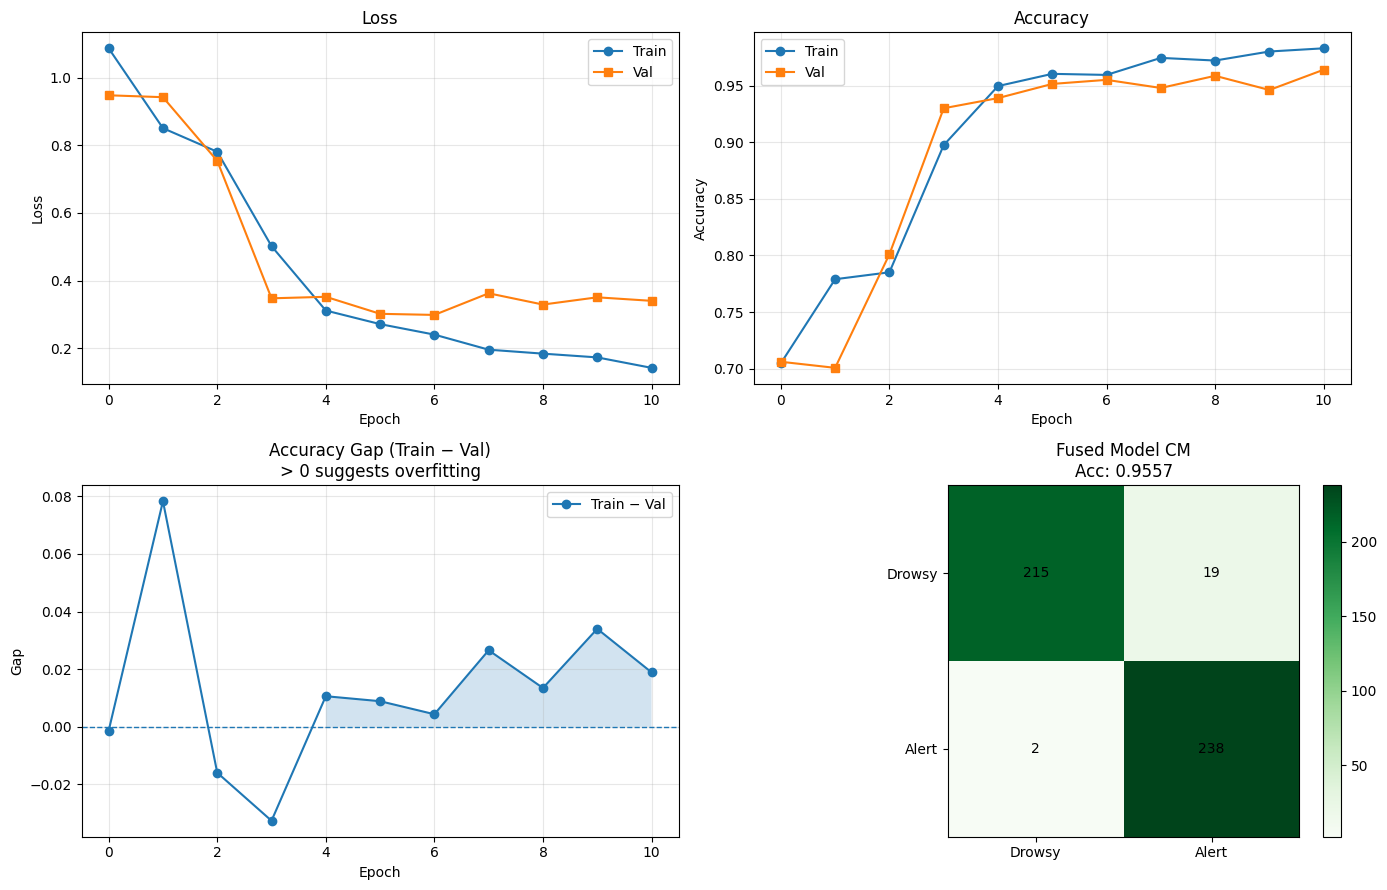

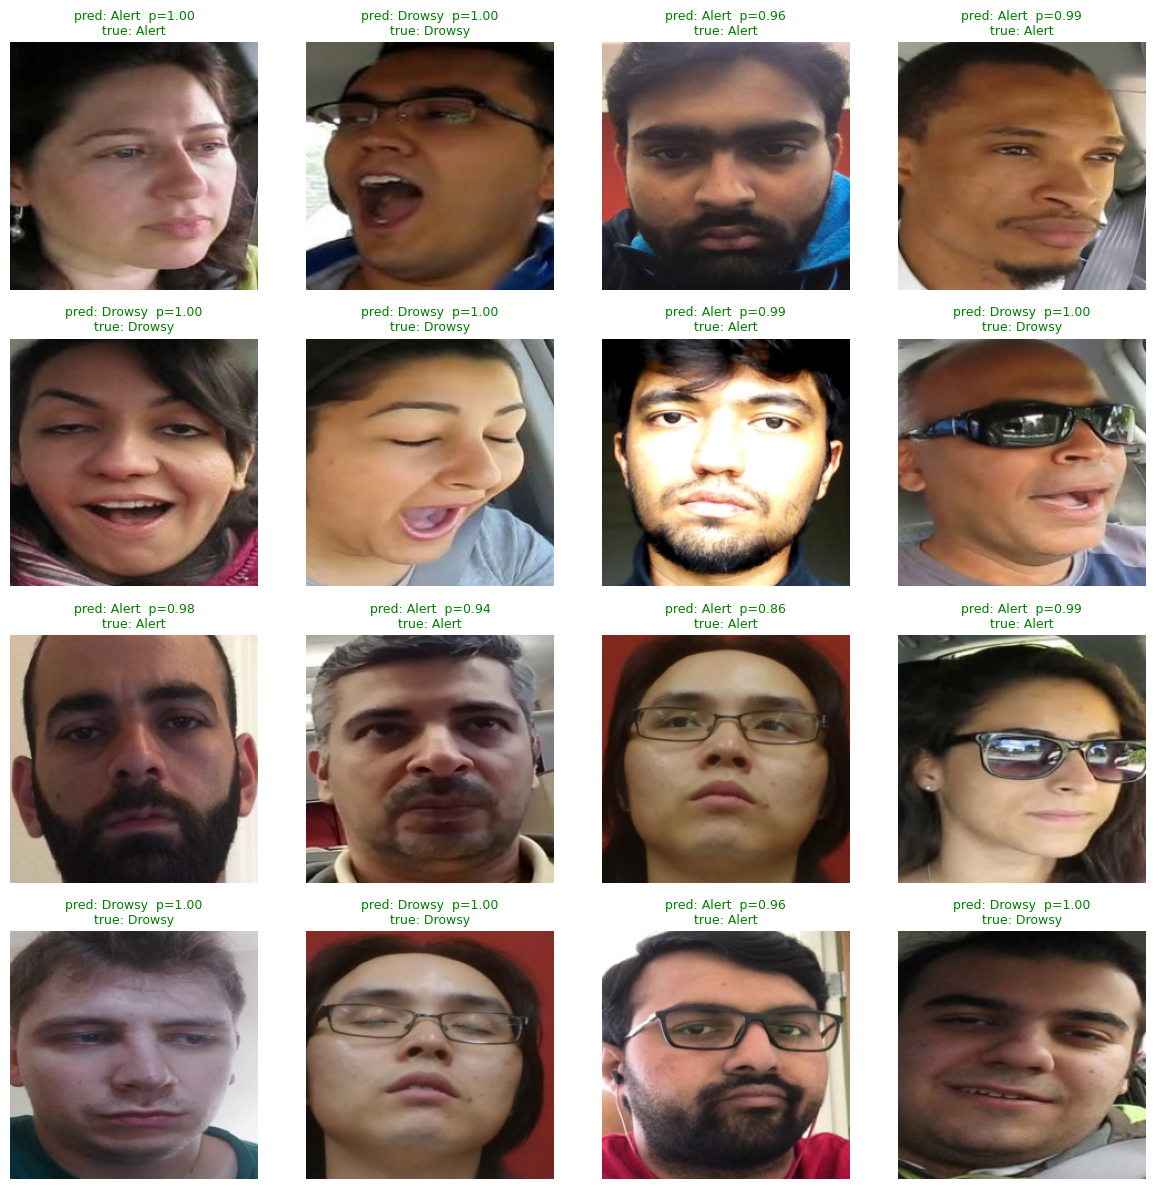


COMPLETE!
Model saved:    model2_multitask\model2_best.pth
Results saved:  model2_multitask\results.json
Figures saved:  model2_multitask\results_overfit_and_cm.png
Val samples:    model2_multitask\val_samples.png


In [16]:
# ========= SAFE SAVE + PLOTS + VISUALIZATION (landmark-dim adaptive) =========
import os, math, json, numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# ----- helpers -----
def write_json(obj, path):
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def _get_expected_lm_dim(model):
    # Try to read model.landmark_fc.in_features; fallback: None
    try:
        return int(getattr(model.landmark_fc, "in_features", None))
    except Exception:
        return None

def _adapt_landmarks(lm: torch.Tensor, expected_dim: int | None):
    """
    Make landmark tensor match expected_dim by slicing or right-padding zeros.
    If expected_dim is None, return lm unchanged.
    """
    if expected_dim is None:
        return lm
    b, d = lm.shape[0], lm.shape[1]
    if d == expected_dim:
        return lm
    if d > expected_dim:
        return lm[:, :expected_dim]
    # pad to the right with zeros
    pad = torch.zeros((b, expected_dim - d), dtype=lm.dtype, device=lm.device)
    return torch.cat([lm, pad], dim=1)

def _denorm(img_t):
    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img = img_t.detach().cpu().permute(1,2,0).numpy()
    img = (img * IMAGENET_STD) + IMAGENET_MEAN
    return np.clip(img, 0, 1)

@torch.no_grad()
def visualize_val_samples(model, val_loader, device, n_images=16, save_path=None):
    """
    Works with loaders yielding either:
      (x, y_d, y_e, y_m, lm)  OR  (x, lm, y_d, y_e, y_m)  OR  (x, lm, y_d)
    Adapts landmark dim to model expectation; prevents matmul shape errors.
    """
    model.eval()
    exp_dim = _get_expected_lm_dim(model)
    imgs, preds, probs, trues = [], [], [], []
    CLASS = ['Drowsy', 'Alert']
    collected = 0

    for batch in val_loader:
        # Normalize tuple order robustly
        if isinstance(batch, (list, tuple)):
            # detect tensors by shape role
            # prefer to find 'x' as 4D tensor (N,C,H,W)
            x = next((t for t in batch if isinstance(t, torch.Tensor) and t.ndim == 4), None)
            # choose a candidate for lm: 2D tensor (N, D) not same object as y's
            lm = next((t for t in batch if isinstance(t, torch.Tensor) and t.ndim == 2 and t is not x), None)
            # choose y_d: 1D/2D long/int tensor (labels)
            y_d = next((t for t in batch if isinstance(t, torch.Tensor) and t.ndim in (1,2) and t is not x and t is not lm), None)
            if x is None or lm is None or y_d is None:
                raise ValueError("val_loader must yield at least (x, lm, y_d).")
        else:
            raise ValueError("val_loader batch must be a tuple/list of tensors.")

        x  = x.to(device, non_blocking=True).float()
        lm = lm.to(device, non_blocking=True).float()
        y_d = y_d.to(device, non_blocking=True).long().view(-1)

        # ADAPT landmark dim to model expectation (slice or pad)
        lm = _adapt_landmarks(lm, exp_dim)

        # Forward
        out = model(x, lm)
        # allow either tuple (logits_d, logits_e, logits_m) or dict
        if isinstance(out, (list, tuple)) and len(out) >= 1:
            logits_d = out[0]
        elif isinstance(out, dict):
            logits_d = out.get('drowsy') or out.get('state')
            if logits_d is None:
                raise RuntimeError("Model dict output missing 'drowsy'/'state' logits.")
        else:
            raise RuntimeError("Unexpected model output; expected tuple/list or dict.")

        p = torch.softmax(logits_d, dim=1)
        conf, pred = torch.max(p, dim=1)

        # Collect
        bsz = x.size(0)
        for i in range(bsz):
            imgs.append(_denorm(x[i]))
            preds.append(int(pred[i].item()))
            probs.append(float(conf[i].item()))
            trues.append(int(y_d[i].item()))
            collected += 1
            if collected >= n_images:
                break
        if collected >= n_images:
            break

    if collected == 0:
        print("No validation images available to visualize.")
        return None

    cols = 4
    rows = math.ceil(collected / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*3.0))
    axes = np.array(axes).reshape(rows, cols)

    for i in range(rows*cols):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        ax.axis('off')
        if i < collected:
            ax.imshow(imgs[i])
            is_correct = (preds[i] == trues[i])
            color = 'green' if is_correct else 'red'
            ax.set_title(
                f"pred: {CLASS[preds[i]]}  p={probs[i]:.2f}\ntrue: {CLASS[trues[i]]}",
                color=color, fontsize=9
            )

    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150)
    plt.show()
    return fig

# ----- ensure dirs -----
MODEL2_DIR = Path(MODEL2_DIR)
MODEL2_DIR.mkdir(parents=True, exist_ok=True)

# ----- (A) Save best weights -----
torch.save(best_state, MODEL2_DIR / "model2_best.pth")

# ----- (B) Metrics, confusion matrices, JSON -----
# Force binary
labels_d_bin = np.clip(np.asarray(labels_d), 0, 1)
base_preds_bin  = np.clip(np.asarray(test_preds['d']), 0, 1)
fused_preds_bin = np.clip(np.asarray(fused_preds),     0, 1)

cm_base  = confusion_matrix(labels_d_bin, base_preds_bin,  labels=[0,1])
cm_fused = confusion_matrix(labels_d_bin, fused_preds_bin, labels=[0,1])

results = {
    "config": CFG,
    "best_epoch": int(best_epoch),
    "best_val_acc": float(best_val_acc),
    "test_acc_base": float(test_acc_base),
    "test_acc_fused": float(test_acc_fused),
    "improvement": float(test_acc_fused - test_acc_base),
    "confusion_matrix_base": cm_base.tolist(),
    "confusion_matrix_fused": cm_fused.tolist(),
}
write_json(results, MODEL2_DIR / "results.json")

# ----- (C) Overfitting diagnostics + fused CM figure -----
hist_train_loss = np.asarray(history['train_loss'], dtype=float)
hist_val_loss   = np.asarray(history['val_loss'],   dtype=float)
hist_train_acc  = np.asarray(history['train_acc'],  dtype=float)
hist_val_acc    = np.asarray(history['val_acc'],    dtype=float)
gap = hist_train_acc - hist_val_acc

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax_loss, ax_acc = axes[0,0], axes[0,1]
ax_gap,  ax_cm  = axes[1,0], axes[1,1]

ax_loss.plot(hist_train_loss, label='Train', marker='o')
ax_loss.plot(hist_val_loss,   label='Val',   marker='s')
ax_loss.set_title('Loss'); ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

ax_acc.plot(hist_train_acc, label='Train', marker='o')
ax_acc.plot(hist_val_acc,   label='Val',   marker='s')
ax_acc.set_title('Accuracy'); ax_acc.set_xlabel('Epoch'); ax_acc.set_ylabel('Accuracy')
ax_acc.legend(); ax_acc.grid(True, alpha=0.3)

ax_gap.plot(gap, marker='o', label='Train − Val')
ax_gap.axhline(0.0, linestyle='--', linewidth=1)
ax_gap.fill_between(np.arange(len(gap)), 0, gap, where=(gap>0), alpha=0.2)
ax_gap.set_title('Accuracy Gap (Train − Val)\n> 0 suggests overfitting')
ax_gap.set_xlabel('Epoch'); ax_gap.set_ylabel('Gap')
ax_gap.legend(); ax_gap.grid(True, alpha=0.3)

im = ax_cm.imshow(cm_fused, cmap='Greens')
ax_cm.set_title(f'Fused Model CM\nAcc: {float(test_acc_fused):.4f}')
ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
ax_cm.set_xticklabels(['Drowsy', 'Alert']); ax_cm.set_yticklabels(['Drowsy', 'Alert'])
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, str(int(cm_fused[i, j])), ha='center', va='center')
fig.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(MODEL2_DIR / "results_overfit_and_cm.png", dpi=150)
plt.show()

# ----- (D) Visualize a gallery from validation set (landmark-dim adaptive) -----
_ = visualize_val_samples(
    model, val_loader, device, n_images=16, save_path=MODEL2_DIR / "val_samples.png"
)

# ----- (E) Final prints -----
print(f"\n{'='*60}")
print("COMPLETE!")
print(f"{'='*60}")
print(f"Model saved:    {MODEL2_DIR / 'model2_best.pth'}")
print(f"Results saved:  {MODEL2_DIR / 'results.json'}")
print(f"Figures saved:  {MODEL2_DIR / 'results_overfit_and_cm.png'}")
print(f"Val samples:    {MODEL2_DIR / 'val_samples.png'}")
print(f"{'='*60}")


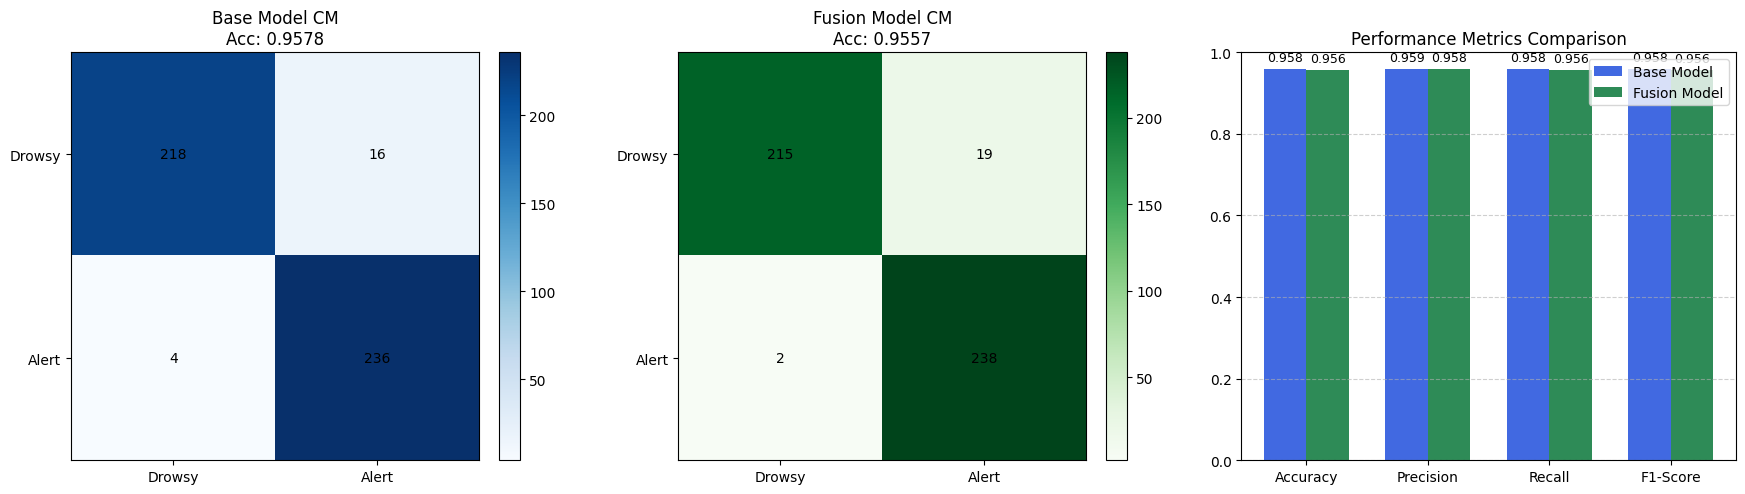


=== Base vs Fusion Model Per-Class Comparison ===

Base Model Classification Report:
              precision    recall  f1-score   support

      Drowsy     0.9820    0.9316    0.9561       234
       Alert     0.9365    0.9833    0.9593       240

    accuracy                         0.9578       474
   macro avg     0.9592    0.9575    0.9577       474
weighted avg     0.9590    0.9578    0.9578       474


Fusion Model Classification Report:
              precision    recall  f1-score   support

      Drowsy     0.9908    0.9188    0.9534       234
       Alert     0.9261    0.9917    0.9577       240

    accuracy                         0.9557       474
   macro avg     0.9584    0.9552    0.9556       474
weighted avg     0.9580    0.9557    0.9556       474



In [17]:
# ---------- COMPARISON PLOTS: BASE vs FUSION ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Base model confusion matrix
im1 = axes[0].imshow(cm_base, cmap='Blues')
axes[0].set_title(f'Base Model CM\nAcc: {test_acc_base:.4f}')
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(['Drowsy', 'Alert']); axes[0].set_yticklabels(['Drowsy', 'Alert'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_base[i, j]), ha='center', va='center')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# 2. Fused model confusion matrix
im2 = axes[1].imshow(cm_fused, cmap='Greens')
axes[1].set_title(f'Fusion Model CM\nAcc: {test_acc_fused:.4f}')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Drowsy', 'Alert']); axes[1].set_yticklabels(['Drowsy', 'Alert'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_fused[i, j]), ha='center', va='center')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Performance metrics comparison
# Calculate metrics for both models
from sklearn.metrics import precision_recall_fscore_support

base_metrics = precision_recall_fscore_support(labels_d, test_preds['d'], average='weighted')
fused_metrics = precision_recall_fscore_support(labels_d, fused_preds, average='weighted')

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_values = [test_acc_base, base_metrics[0], base_metrics[1], base_metrics[2]]
fused_values = [test_acc_fused, fused_metrics[0], fused_metrics[1], fused_metrics[2]]

# Create grouped bar chart
x = np.arange(len(metric_names))
width = 0.35

axes[2].bar(x - width/2, base_values, width, label='Base Model', color='royalblue')
axes[2].bar(x + width/2, fused_values, width, label='Fusion Model', color='seagreen')

axes[2].set_title('Performance Metrics Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metric_names)
axes[2].set_ylim(0, 1.0)
axes[2].legend()
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

# Add value labels on top of bars
for i, v in enumerate(base_values):
    axes[2].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
for i, v in enumerate(fused_values):
    axes[2].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(MODEL2_DIR / "comparison_base_vs_fusion.png", dpi=150)
plt.show()

# You can also add a per-class metrics comparison if needed
print("\n=== Base vs Fusion Model Per-Class Comparison ===")
print("\nBase Model Classification Report:")
print(classification_report(labels_d, test_preds['d'], target_names=['Drowsy', 'Alert'], digits=4))
print("\nFusion Model Classification Report:")
print(classification_report(labels_d, fused_preds, target_names=['Drowsy', 'Alert'], digits=4))